In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd

df1 = pd.read_csv("/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/data/CRMLSSold202512.csv")
df2 = pd.read_csv("/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/data/CRMLSSold202601.csv")
df3 = pd.read_csv("/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/data/CRMLSSold202602.csv")
df4 = pd.read_csv("/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/data/CRMLSSold202603.csv")
df5 = pd.read_csv("/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/data/CRMLSSold202604.csv")
df6 = pd.read_csv("/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/data/CRMLSSold202605.csv")


/tmp/ipykernel_16404/4211889715.py:4: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/data/CRMLSSold202601.csv")


In [4]:
df_original = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)
df = df_original.copy()

#**EDA**
With **ClosePrice(Target Variable), LivingArea, Bedrooms, Bathrooms, and LotSize**

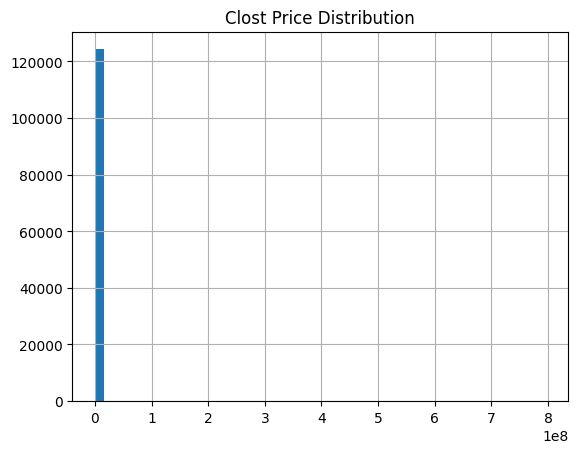

In [5]:
df['ClosePrice'].hist(bins=50)
plt.title("Clost Price Distribution")
plt.show()

In [6]:
df['ClosePrice'].describe()

,ClosePrice
count,1.244030e+05
mean,8.976399e+05
std,6.508684e+06
min,0.000000e+00
25%,2.700000e+04
50%,6.170000e+05
75%,1.060000e+06
max,7.960000e+08


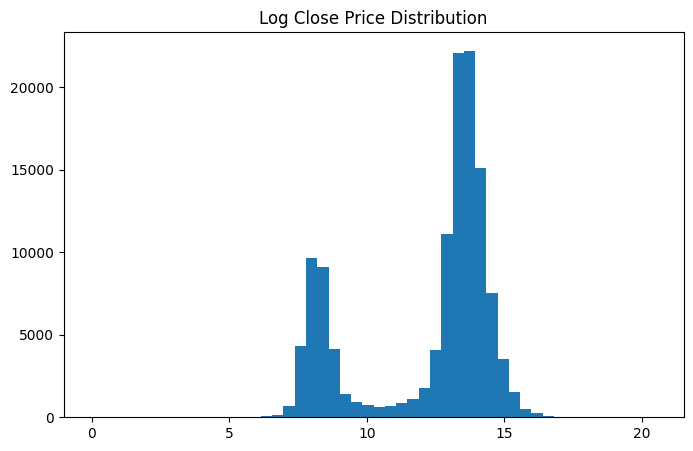

In [7]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df['ClosePrice']), bins=50)
plt.title("Log Close Price Distribution")
plt.show()

### **NOTES**

The ClosePrice distribution is highly right-skewed. As we can see in the above describe information, the median price is \$617,000 while the mean is around \$898,000, indicating the presence of high-value outliers. The dataset also contains properties with a ClosePrice of 0 and maximum value of \$796 million, which should be investigated during data cleaning.

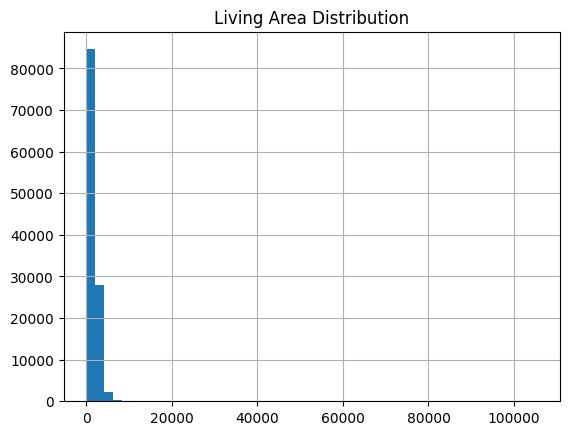

In [8]:
df['LivingArea'].hist(bins=50)
plt.title("Living Area Distribution")
plt.show()

In [9]:
df['LivingArea'].describe()

,LivingArea
count,115644.000000
mean,1817.942472
std,1238.080953
min,0.000000
25%,1178.000000
50%,1582.000000
75%,2168.000000
max,105369.000000


In [10]:
df[df['LivingArea'] == 0].shape

(98, 78)

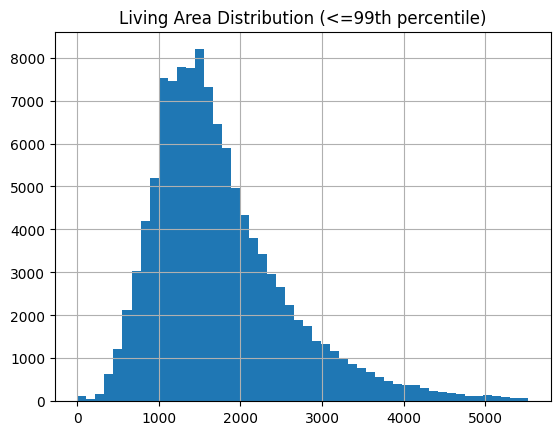

In [11]:
df[df['LivingArea'] <= df['LivingArea'].quantile(0.99)]['LivingArea'].hist(bins=50)
plt.title("Living Area Distribution (<=99th percentile)")
plt.show()

### **NOTES**

The LivingArea distribution is right-skewed. Most homes are ranging from around 1,000 to 2,500 sqft. The median LivingArea is 1,582 sqft, while the mean is around 1,818 sqft. The dataset contains several extreme outliers, including a maximum value of 105,369 sqft, as well as 98 records with a LivingArea of 0 sqft. These values should be reviewed during data cleaning.

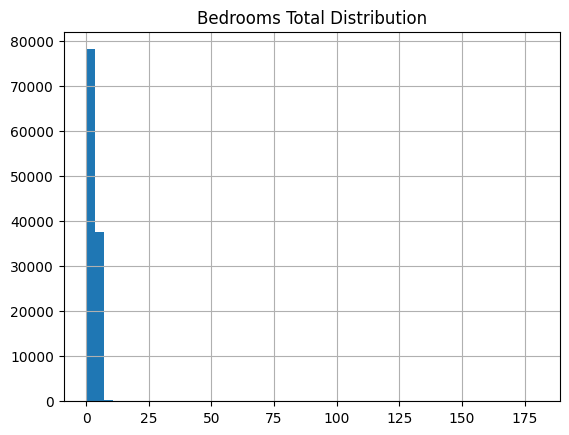

In [12]:
df['BedroomsTotal'].hist(bins=50)
plt.title("Bedrooms Total Distribution")
plt.show()

In [13]:
df['BedroomsTotal'].describe()

,BedroomsTotal
count,116208.000000
mean,3.089366
std,1.548127
min,0.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,180.000000


In [14]:
df['BedroomsTotal'].value_counts().sort_index()

,count
BedroomsTotal,
0.0,1055
1.0,6995
2.0,27569
3.0,42552
4.0,27465
5.0,8236
6.0,1518
7.0,335
8.0,157


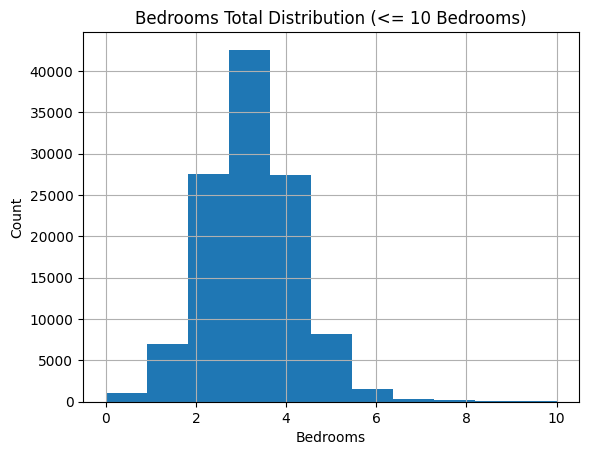

In [15]:
df[df['BedroomsTotal'] <= 10]['BedroomsTotal'].hist(bins=11)

plt.title("Bedrooms Total Distribution (<= 10 Bedrooms)")
plt.xlabel("Bedrooms")
plt.ylabel("Count")
plt.show()

### **NOTES**

The BedroomsTotal distribution is concentrated around 3-bedroom homes, with most properties containing between 2 and 4 bedrooms. The dataset contains several extreme outliers, including a maximum value of 180 bedrooms, as well as 1055 records with a BedroomsTotal of 0. These values should be reviewed during data cleaning.

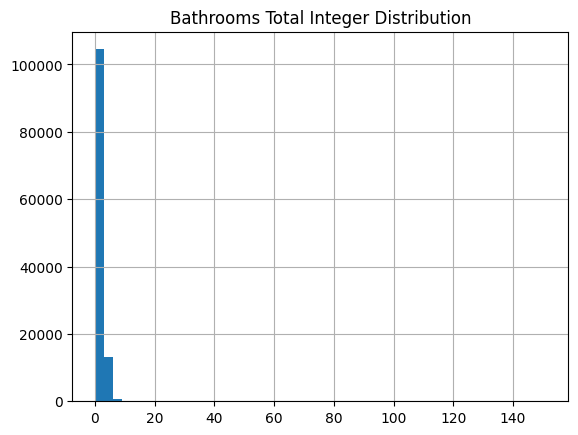

In [16]:
df['BathroomsTotalInteger'].hist(bins=50)
plt.title("Bathrooms Total Integer Distribution")
plt.show()

In [17]:
df['BathroomsTotalInteger'].describe()

,BathroomsTotalInteger
count,118729.000000
mean,2.462676
std,1.502207
min,0.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,151.000000


In [18]:
df['BathroomsTotalInteger'].value_counts().sort_index()

,count
BathroomsTotalInteger,
0.0,2637
1.0,16816
2.0,48712
3.0,36341
4.0,8661
5.0,3200
6.0,1298
7.0,469
8.0,232


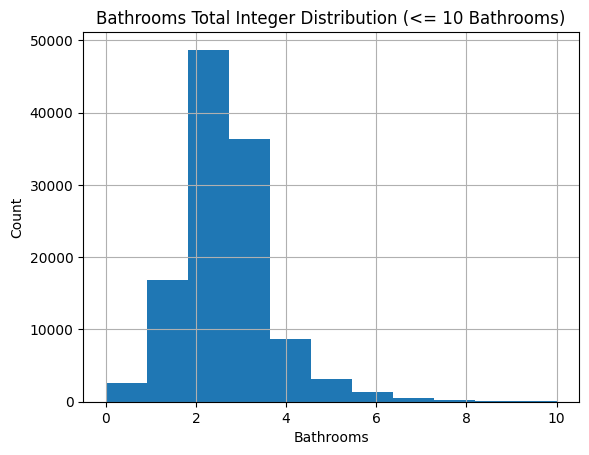

In [19]:
df[df['BathroomsTotalInteger'] <= 10]['BathroomsTotalInteger'].hist(bins=11)

plt.title("Bathrooms Total Integer Distribution (<= 10 Bathrooms)")
plt.xlabel("Bathrooms")
plt.ylabel("Count")
plt.show()

### **NOTES**

The BathroomsTotalInteger distribution is concentrated around 2-bathroom homes, with most properties containing between 1 and 3 bathrooms. The dataset contains several extreme outliers, including a maximum value of 151 bathrooms, as well as 2637 records with a BathroomsTotalInteger of 0. These values should be reviewed during data cleaning.

In [88]:
df['LotSizeSquareFeet'].hist(bins=50)
plt.title("Lot Size Square Feet Distribution")
plt.show()

KeyboardInterrupt: 

In [20]:
df['LotSizeSquareFeet'].describe()

,LotSizeSquareFeet
count,1.140490e+05
mean,5.204247e+05
std,2.448794e+07
min,0.000000e+00
25%,5.227000e+03
50%,7.405000e+03
75%,1.374900e+04
max,5.193920e+09


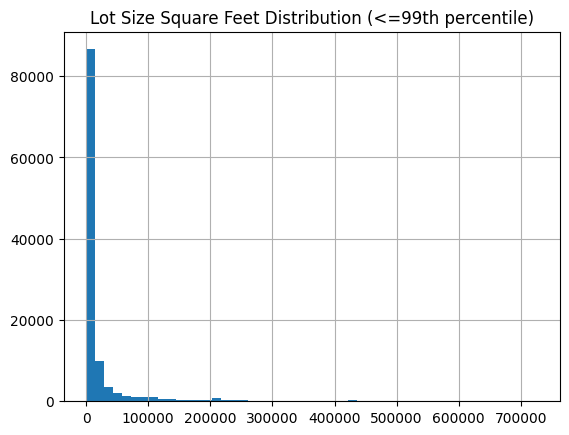

In [21]:
df[df['LotSizeSquareFeet'] <= df['LotSizeSquareFeet'].quantile(0.99)]['LotSizeSquareFeet'].hist(bins=50)
plt.title("Lot Size Square Feet Distribution (<=99th percentile)")
plt.show()

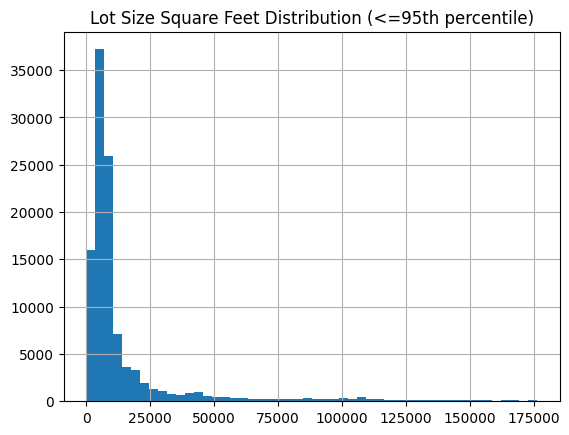

In [22]:
df[df['LotSizeSquareFeet'] <= df['LotSizeSquareFeet'].quantile(0.95)]['LotSizeSquareFeet'].hist(bins=50)
plt.title("Lot Size Square Feet Distribution (<=95th percentile)")
plt.show()

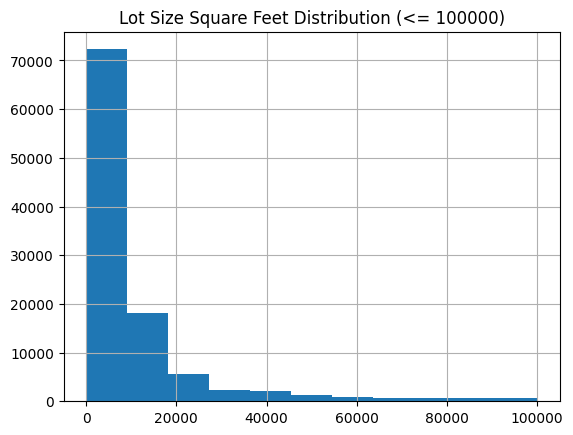

In [23]:
df[df['LotSizeSquareFeet'] <= 100000]['LotSizeSquareFeet'].hist(bins=11)
plt.title("Lot Size Square Feet Distribution (<= 100000)")
plt.show()

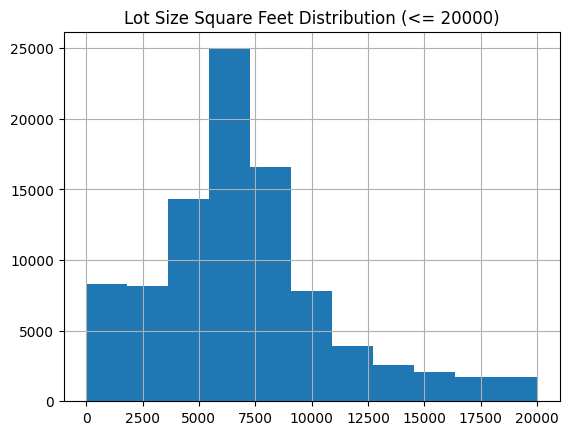

In [24]:
df[df['LotSizeSquareFeet'] <= 20000]['LotSizeSquareFeet'].hist(bins=11)
plt.title("Lot Size Square Feet Distribution (<= 20000)")
plt.show()

### **NOTES**

The LotSizeSquareFeet distribution is highly right-skewed. Most properties occupy relatively small lots, typically between 3,000 and 11,000 square feet, while a small number of extremely large parcels create a long right tail. The presence of zero-valued records and extreme outliers indicates that data cleaning will be necessary before modeling.

In [25]:
df_sf = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
].copy()